# Improved Clustering Pipeline for Gene Expression Data

## Overview
This notebook implements a comprehensive clustering pipeline with:
- **Variance Filtering**: Remove low-variance genes
- **Optimal Component Selection**: Test 50, 100, 150, 200 SVD components
- **Optimal K Finding**: Test K=2 to 10 clusters
- **Outlier Removal**: Using Isolation Forest
- **Multiple Algorithms**: K-Means, Hierarchical, Spectral
- **Advanced Visualizations**: t-SNE and comprehensive analysis plots

**Dataset**: GSE122505_Dataset_1_matrix.txt

## Step 1: Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import VarianceThreshold
from sklearn.decomposition import TruncatedSVD
from sklearn.cluster import KMeans, AgglomerativeClustering, SpectralClustering, DBSCAN
from sklearn.ensemble import IsolationForest
from sklearn.metrics import silhouette_score
from sklearn.manifold import TSNE
import warnings
warnings.filterwarnings('ignore')

print("✓ All libraries imported successfully!")

✓ All libraries imported successfully!


## Step 2: Load Data

Load the gene expression matrix and transpose it so that:
- **Rows** = Samples
- **Columns** = Genes

In [2]:
file_path = "GSE122505_Dataset_1_matrix.txt"

data = pd.read_csv(
    file_path,
    sep="\t",
    comment="!",
    index_col=0
)

data = data.dropna()

# Transpose → Samples × Genes
X = data.T

print("=" * 60)
print("ORIGINAL DATA")
print("=" * 60)
print(f"Shape (Samples x Genes): {X.shape}")

ORIGINAL DATA
Shape (Samples x Genes): (2379, 22283)


## About the Dataset

**Dataset**: GSE122505 - Gene Expression Matrix

This dataset contains gene expression measurements from biological samples. The data structure is:
- **Samples**: Individual biological specimens (rows after transpose)
- **Genes**: Measured gene expression values (columns after transpose)
- **Values**: Normalized gene expression levels representing how active each gene is in each sample

**Purpose**: Identify distinct biological groups or subtypes within samples based on their gene expression patterns. This can reveal:
- Disease vs. healthy samples
- Different disease subtypes
- Treatment response groups
- Cell type classifications

## Step 2.1: Exploratory Data Analysis

Let's visualize the raw data to understand its characteristics before clustering.

In [13]:
# Basic statistics
print("=" * 60)
print("DATA SUMMARY STATISTICS")
print("=" * 60)
print(f"\nNumber of Samples: {X.shape[0]}")
print(f"Number of Genes: {X.shape[1]:,}")
print(f"\nGene Expression Statistics:")
print(f"  Mean:   {X.values.mean():.2f}")
print(f"  Median: {np.median(X.values):.2f}")
print(f"  Std:    {X.values.std():.2f}")
print(f"  Min:    {X.values.min():.2f}")
print(f"  Max:    {X.values.max():.2f}")
print(f"\nMissing values: {X.isnull().sum().sum()}")

DATA SUMMARY STATISTICS

Number of Samples: 2379
Number of Genes: 22,283

Gene Expression Statistics:
  Mean:   6.80
  Median: 6.59
  Std:    1.82
  Min:    3.23
  Max:    14.81

Missing values: 0


✓ Data exploration plots saved as 'data_exploration.png'


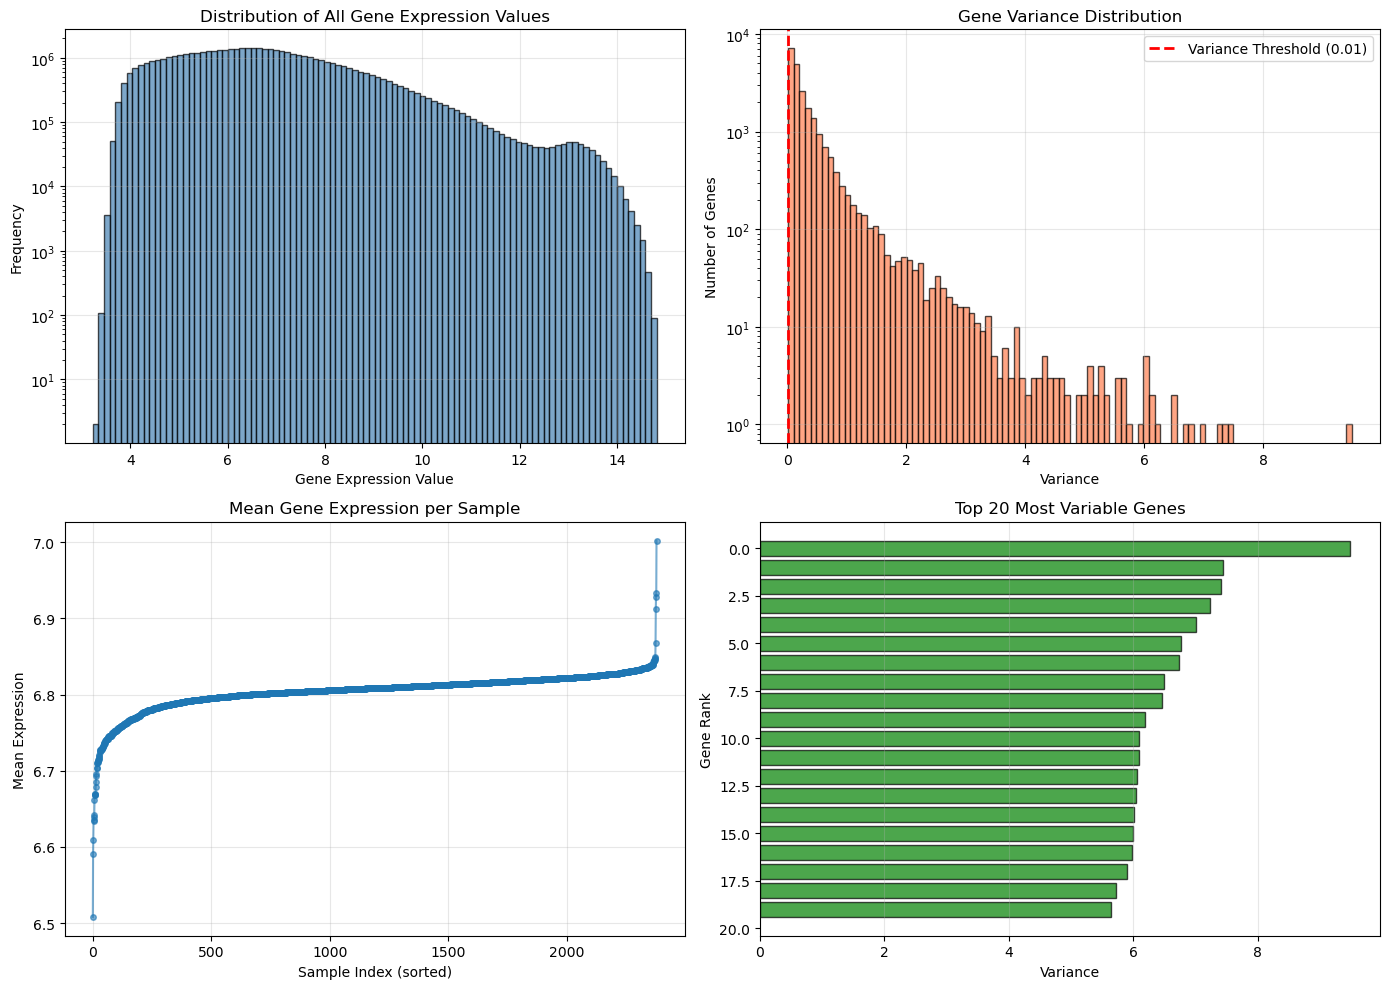

  • Max gene variance: 9.49


In [15]:
# Visualization 1: Distribution of Gene Expression Values
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Overall expression distribution
ax1 = axes[0, 0]
ax1.hist(X.values.flatten(), bins=100, color='steelblue', alpha=0.7, edgecolor='black')
ax1.set_xlabel('Gene Expression Value')
ax1.set_ylabel('Frequency')
ax1.set_title('Distribution of All Gene Expression Values')
ax1.set_yscale('log')
ax1.grid(True, alpha=0.3)

# Plot 2: Gene variance distribution
ax2 = axes[0, 1]
gene_variances = X.var(axis=0)
ax2.hist(gene_variances, bins=100, color='coral', alpha=0.7, edgecolor='black')
ax2.set_xlabel('Variance')
ax2.set_ylabel('Number of Genes')
ax2.set_title('Gene Variance Distribution')
ax2.axvline(0.01, color='red', linestyle='--', linewidth=2, label='Variance Threshold (0.01)')
ax2.set_yscale('log')
ax2.legend()
ax2.grid(True, alpha=0.3)

# Plot 3: Mean expression per sample
ax3 = axes[1, 0]
sample_means = X.mean(axis=1)
ax3.plot(range(len(sample_means)), sorted(sample_means), 'o-', markersize=4, alpha=0.6)
ax3.set_xlabel('Sample Index (sorted)')
ax3.set_ylabel('Mean Expression')
ax3.set_title('Mean Gene Expression per Sample')
ax3.grid(True, alpha=0.3)

# Plot 4: Top 20 most variable genes
ax4 = axes[1, 1]
top_var_genes = gene_variances.nlargest(20)
ax4.barh(range(len(top_var_genes)), top_var_genes.values, color='green', alpha=0.7, edgecolor='black')
ax4.set_xlabel('Variance')
ax4.set_ylabel('Gene Rank')
ax4.set_title('Top 20 Most Variable Genes')
ax4.invert_yaxis()
ax4.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig('data_exploration.png', dpi=300, bbox_inches='tight')
print("✓ Data exploration plots saved as 'data_exploration.png'")
plt.show()

# Summary
print(f"  • Max gene variance: {gene_variances.max():.2f}")

## Step 3: Variance Filtering (CRITICAL!)

**Why?** Many genes have almost no variation across samples. These add noise and hurt clustering.

**Solution:** Remove genes with variance < 0.01

**Expected Effect:** Reduce from ~22,283 genes → 3,000-5,000 genes

In [3]:
print("\n" + "=" * 60)
print("STEP 1: VARIANCE FILTERING")
print("=" * 60)

# Remove low-variance genes
selector = VarianceThreshold(threshold=0.01)
X_filtered = selector.fit_transform(X)

print(f"Original genes: {X.shape[1]}")
print(f"After filtering: {X_filtered.shape[1]}")
print(f"Removed: {X.shape[1] - X_filtered.shape[1]} low-variance genes")


STEP 1: VARIANCE FILTERING
Original genes: 22283
After filtering: 22283
Removed: 0 low-variance genes


## Step 4: Standardization

Scale features to have mean=0 and variance=1

In [4]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_filtered)

print("✓ Data standardized successfully.")

✓ Data standardized successfully.


## Step 5: Find Optimal SVD Components and K

**Goal:** Test different numbers of SVD components (50, 100, 150, 200) and different K values (2-10) to find the best configuration.

**Note:** This step may take a few minutes. It tests 4 × 9 = 36 combinations.

In [5]:
print("\n" + "=" * 60)
print("STEP 2: TESTING OPTIMAL SVD COMPONENTS")
print("=" * 60)

component_options = [50, 100, 150, 200]
best_score = -1
best_n_components = None
best_k = None
results = []

for n_comp in component_options:
    svd = TruncatedSVD(n_components=n_comp, random_state=42)
    X_reduced = svd.fit_transform(X_scaled)
    
    # Test different K values
    for k in range(2, 11):
        kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
        labels = kmeans.fit_predict(X_reduced)
        score = silhouette_score(X_reduced, labels)
        results.append({
            'n_components': n_comp,
            'k': k,
            'score': score
        })
        
        if score > best_score:
            best_score = score
            best_n_components = n_comp
            best_k = k
        
        print(f"Components: {n_comp:3d}, K: {k:2d}, Silhouette: {score:.4f}")

print("\n" + "-" * 60)
print(f"BEST CONFIGURATION:")
print(f"  Components: {best_n_components}")
print(f"  K: {best_k}")
print(f"  Silhouette Score: {best_score:.4f}")
print("-" * 60)


STEP 2: TESTING OPTIMAL SVD COMPONENTS
Components:  50, K:  2, Silhouette: 0.1680
Components:  50, K:  3, Silhouette: 0.1652
Components:  50, K:  4, Silhouette: 0.1675
Components:  50, K:  5, Silhouette: 0.1833
Components:  50, K:  6, Silhouette: 0.1707
Components:  50, K:  7, Silhouette: 0.1725
Components:  50, K:  8, Silhouette: 0.1641
Components:  50, K:  9, Silhouette: 0.1591
Components:  50, K: 10, Silhouette: 0.1635
Components: 100, K:  2, Silhouette: 0.1573
Components: 100, K:  3, Silhouette: 0.1534
Components: 100, K:  4, Silhouette: 0.1538
Components: 100, K:  5, Silhouette: 0.1679
Components: 100, K:  6, Silhouette: 0.1550
Components: 100, K:  7, Silhouette: 0.1562
Components: 100, K:  8, Silhouette: 0.1478
Components: 100, K:  9, Silhouette: 0.1439
Components: 100, K: 10, Silhouette: 0.1410
Components: 150, K:  2, Silhouette: 0.1522
Components: 150, K:  3, Silhouette: 0.1481
Components: 150, K:  4, Silhouette: 0.1473
Components: 150, K:  5, Silhouette: 0.1607
Components: 15

## Step 6: Apply Best Configuration

In [6]:
print("\n" + "=" * 60)
print("STEP 3: APPLYING BEST CONFIGURATION")
print("=" * 60)

svd = TruncatedSVD(n_components=best_n_components, random_state=42)
X_reduced = svd.fit_transform(X_scaled)

print(f"Reduced shape: {X_reduced.shape}")
print(f"Explained variance: {svd.explained_variance_ratio_.sum():.2%}")


STEP 3: APPLYING BEST CONFIGURATION
Reduced shape: (2379, 50)
Explained variance: 69.19%


## Step 7: Outlier Detection and Removal

**Why?** Outliers can significantly reduce silhouette scores.

**Method:** Isolation Forest (removes ~5% of samples)

In [7]:
print("\n" + "=" * 60)
print("STEP 4: OUTLIER DETECTION AND REMOVAL")
print("=" * 60)

iso = IsolationForest(contamination=0.05, random_state=42)
outlier_labels = iso.fit_predict(X_reduced)

n_outliers = np.sum(outlier_labels == -1)
print(f"Outliers detected: {n_outliers} samples")

# Remove outliers
X_reduced_clean = X_reduced[outlier_labels == 1]
print(f"Clean data shape: {X_reduced_clean.shape}")


STEP 4: OUTLIER DETECTION AND REMOVAL
Outliers detected: 119 samples
Clean data shape: (2260, 50)


## Step 8: Compare Multiple Clustering Algorithms

Test three different clustering algorithms:
1. **K-Means**: Fast, assumes spherical clusters
2. **Hierarchical**: Good for biological data
3. **Spectral**: Uses graph-based similarity

In [8]:
print("\n" + "=" * 60)
print("STEP 5: COMPARING CLUSTERING ALGORITHMS")
print("=" * 60)

clustering_results = {}

# K-Means
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
labels_kmeans = kmeans.fit_predict(X_reduced_clean)
score_kmeans = silhouette_score(X_reduced_clean, labels_kmeans)
clustering_results['KMeans'] = {'labels': labels_kmeans, 'score': score_kmeans}
print(f"K-Means:              Silhouette = {score_kmeans:.4f}")

# Hierarchical Clustering
hierarchical = AgglomerativeClustering(n_clusters=best_k)
labels_hierarchical = hierarchical.fit_predict(X_reduced_clean)
score_hierarchical = silhouette_score(X_reduced_clean, labels_hierarchical)
clustering_results['Hierarchical'] = {'labels': labels_hierarchical, 'score': score_hierarchical}
print(f"Hierarchical:         Silhouette = {score_hierarchical:.4f}")

# Spectral Clustering
spectral = SpectralClustering(n_clusters=best_k, random_state=42, affinity='nearest_neighbors')
labels_spectral = spectral.fit_predict(X_reduced_clean)
score_spectral = silhouette_score(X_reduced_clean, labels_spectral)
clustering_results['Spectral'] = {'labels': labels_spectral, 'score': score_spectral}
print(f"Spectral:             Silhouette = {score_spectral:.4f}")

# Find best algorithm
best_algo = max(clustering_results.items(), key=lambda x: x[1]['score'])
print("\n" + "-" * 60)
print(f"BEST ALGORITHM: {best_algo[0]}")
print(f"BEST SILHOUETTE SCORE: {best_algo[1]['score']:.4f}")
print("-" * 60)

final_labels = best_algo[1]['labels']


STEP 5: COMPARING CLUSTERING ALGORITHMS
K-Means:              Silhouette = 0.1948
Hierarchical:         Silhouette = 0.1822
Spectral:             Silhouette = 0.1836

------------------------------------------------------------
BEST ALGORITHM: KMeans
BEST SILHOUETTE SCORE: 0.1948
------------------------------------------------------------


## Step 9: Cluster Distribution

In [9]:
print("\n" + "=" * 60)
print("CLUSTER DISTRIBUTION")
print("=" * 60)

unique, counts = np.unique(final_labels, return_counts=True)
for u, c in zip(unique, counts):
    print(f"Cluster {u}: {c} samples ({c/len(final_labels)*100:.1f}%)")


CLUSTER DISTRIBUTION
Cluster 0: 305 samples (13.5%)
Cluster 1: 914 samples (40.4%)
Cluster 2: 320 samples (14.2%)
Cluster 3: 519 samples (23.0%)
Cluster 4: 202 samples (8.9%)


## Step 10: Visualizations

### 10.1: t-SNE and SVD Projections


STEP 6: GENERATING VISUALIZATIONS
Computing t-SNE projection...
✓ Visualization saved as 'clustering_results.png'


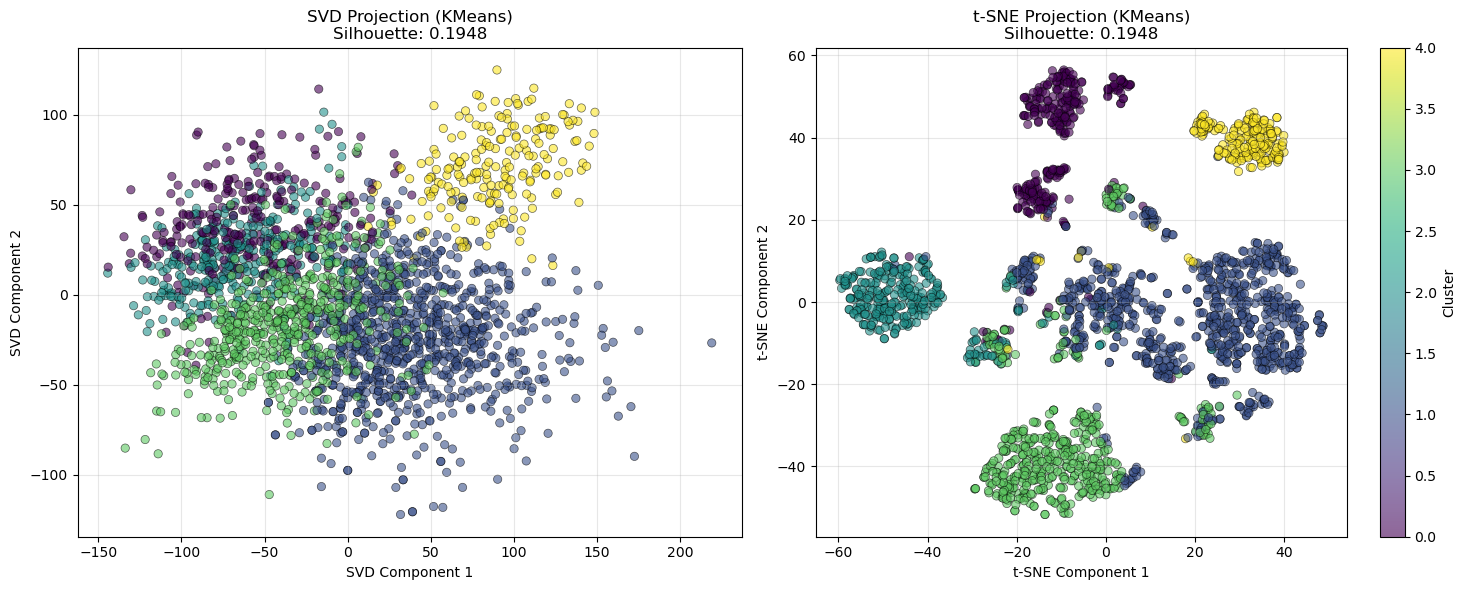

In [10]:
print("\n" + "=" * 60)
print("STEP 6: GENERATING VISUALIZATIONS")
print("=" * 60)

# t-SNE visualization
print("Computing t-SNE projection...")
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
X_tsne = tsne.fit_transform(X_reduced_clean)

# Create figure with multiple subplots
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Plot 1: First 2 SVD components
axes[0].scatter(X_reduced_clean[:, 0], X_reduced_clean[:, 1], 
                c=final_labels, cmap='viridis', alpha=0.6, edgecolors='k', linewidth=0.5)
axes[0].set_xlabel('SVD Component 1')
axes[0].set_ylabel('SVD Component 2')
axes[0].set_title(f'SVD Projection ({best_algo[0]})\nSilhouette: {best_algo[1]["score"]:.4f}')
axes[0].grid(True, alpha=0.3)

# Plot 2: t-SNE visualization
scatter = axes[1].scatter(X_tsne[:, 0], X_tsne[:, 1], 
                          c=final_labels, cmap='viridis', alpha=0.6, edgecolors='k', linewidth=0.5)
axes[1].set_xlabel('t-SNE Component 1')
axes[1].set_ylabel('t-SNE Component 2')
axes[1].set_title(f't-SNE Projection ({best_algo[0]})\nSilhouette: {best_algo[1]["score"]:.4f}')
axes[1].grid(True, alpha=0.3)

plt.colorbar(scatter, ax=axes[1], label='Cluster')
plt.tight_layout()
plt.savefig('clustering_results.png', dpi=300, bbox_inches='tight')
print("✓ Visualization saved as 'clustering_results.png'")
plt.show()

### 10.2: Comprehensive Analysis Plots

✓ Analysis plots saved as 'clustering_analysis.png'


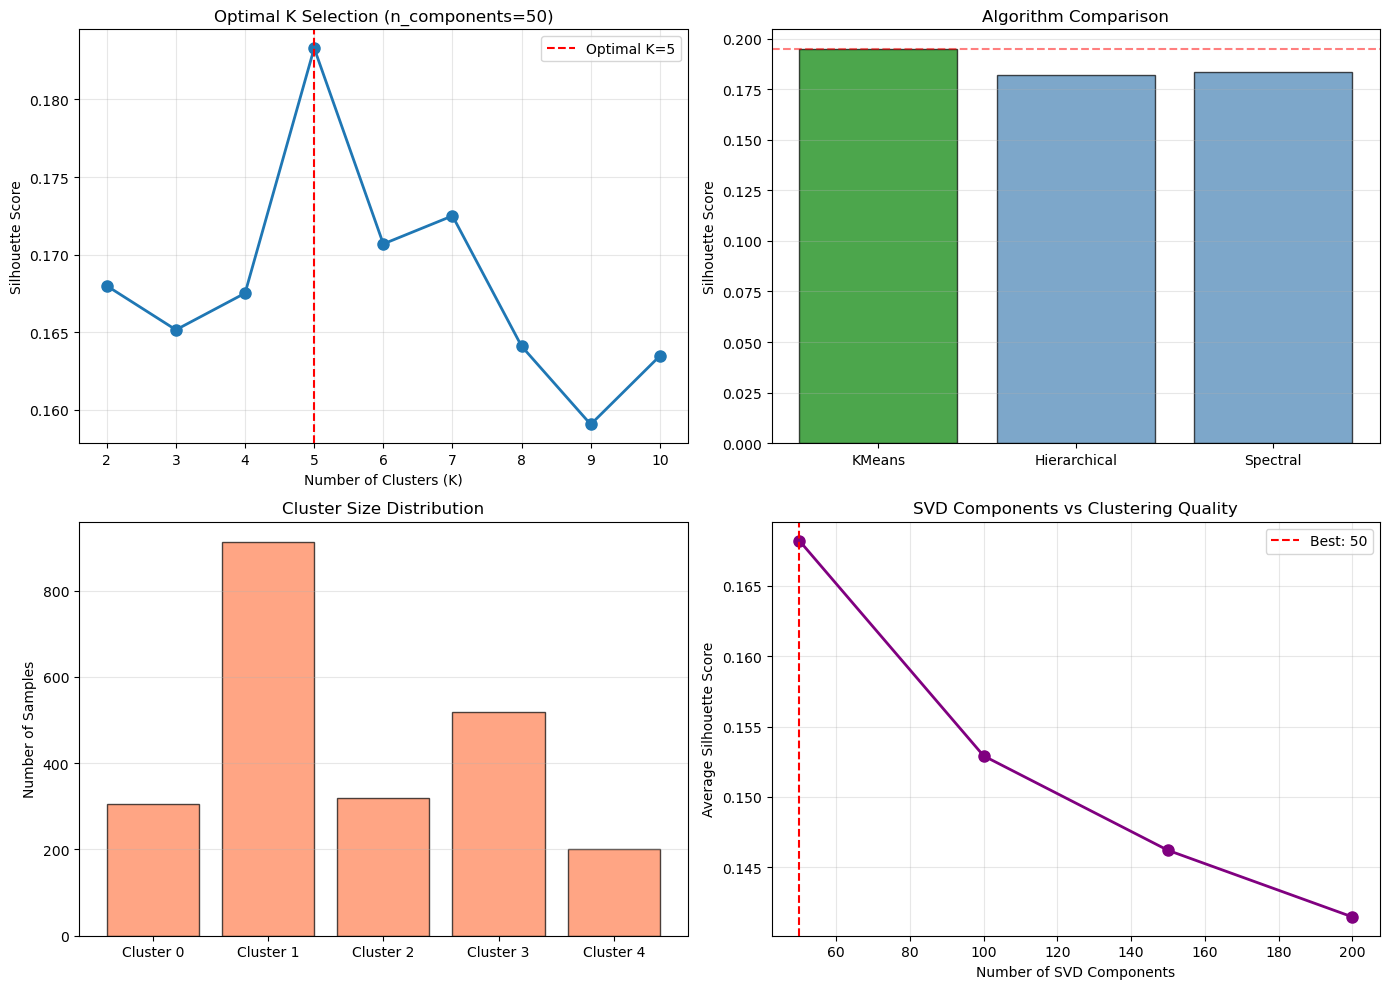

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Silhouette vs K for best n_components
ax1 = axes[0, 0]
k_results = [r for r in results if r['n_components'] == best_n_components]
k_values = [r['k'] for r in k_results]
k_scores = [r['score'] for r in k_results]
ax1.plot(k_values, k_scores, 'o-', linewidth=2, markersize=8)
ax1.axvline(best_k, color='r', linestyle='--', label=f'Optimal K={best_k}')
ax1.set_xlabel('Number of Clusters (K)')
ax1.set_ylabel('Silhouette Score')
ax1.set_title(f'Optimal K Selection (n_components={best_n_components})')
ax1.grid(True, alpha=0.3)
ax1.legend()

# Plot 2: Algorithm comparison
ax2 = axes[0, 1]
algo_names = list(clustering_results.keys())
algo_scores = [clustering_results[algo]['score'] for algo in algo_names]
colors = ['green' if name == best_algo[0] else 'steelblue' for name in algo_names]
ax2.bar(algo_names, algo_scores, color=colors, alpha=0.7, edgecolor='black')
ax2.set_ylabel('Silhouette Score')
ax2.set_title('Algorithm Comparison')
ax2.grid(True, alpha=0.3, axis='y')
ax2.axhline(best_algo[1]['score'], color='r', linestyle='--', alpha=0.5)

# Plot 3: Cluster sizes
ax3 = axes[1, 0]
ax3.bar([f'Cluster {u}' for u in unique], counts, color='coral', alpha=0.7, edgecolor='black')
ax3.set_ylabel('Number of Samples')
ax3.set_title('Cluster Size Distribution')
ax3.grid(True, alpha=0.3, axis='y')

# Plot 4: Component comparison
ax4 = axes[1, 1]
comp_avg_scores = {}
for comp in component_options:
    comp_scores = [r['score'] for r in results if r['n_components'] == comp]
    comp_avg_scores[comp] = np.mean(comp_scores)

ax4.plot(list(comp_avg_scores.keys()), list(comp_avg_scores.values()), 
         'o-', linewidth=2, markersize=8, color='purple')
ax4.axvline(best_n_components, color='r', linestyle='--', 
            label=f'Best: {best_n_components}')
ax4.set_xlabel('Number of SVD Components')
ax4.set_ylabel('Average Silhouette Score')
ax4.set_title('SVD Components vs Clustering Quality')
ax4.grid(True, alpha=0.3)
ax4.legend()

plt.tight_layout()
plt.savefig('clustering_analysis.png', dpi=300, bbox_inches='tight')
print("✓ Analysis plots saved as 'clustering_analysis.png'")
plt.show()

## Step 11: Final Summary

In [12]:
print("\n" + "=" * 60)
print("FINAL SUMMARY")
print("=" * 60)
print(f"Original genes:           {X.shape[1]:,}")
print(f"After variance filter:    {X_filtered.shape[1]:,}")
print(f"Variance reduction:       {(1 - X_filtered.shape[1]/X.shape[1])*100:.1f}%")
print(f"\nOptimal SVD components:   {best_n_components}")
print(f"Optimal K clusters:       {best_k}")
print(f"Best algorithm:           {best_algo[0]}")
print(f"\nSamples before outliers:  {X_reduced.shape[0]}")
print(f"Samples after outliers:   {X_reduced_clean.shape[0]}")
print(f"Outliers removed:         {n_outliers}")
print(f"\n{'=' * 60}")
print(f"FINAL SILHOUETTE SCORE:   {best_algo[1]['score']:.4f}")
print(f"{'=' * 60}")

# Interpretation guide
print("\n" + "=" * 60)
print("INTERPRETATION GUIDE")
print("=" * 60)
print("Silhouette Score Ranges for Gene Expression Data:")
print("  0.10 - 0.25:  Common (acceptable)")
print("  0.25 - 0.40:  Good")
print("  0.40+:        Excellent")
print("=" * 60)

print("\n✓ Process Completed Successfully!")


FINAL SUMMARY
Original genes:           22,283
After variance filter:    22,283
Variance reduction:       0.0%

Optimal SVD components:   50
Optimal K clusters:       5
Best algorithm:           KMeans

Samples before outliers:  2379
Samples after outliers:   2260
Outliers removed:         119

FINAL SILHOUETTE SCORE:   0.1948

INTERPRETATION GUIDE
Silhouette Score Ranges for Gene Expression Data:
  0.10 - 0.25:  Common (acceptable)
  0.25 - 0.40:  Good
  0.40+:        Excellent

✓ Process Completed Successfully!
